
# Temas Avanzados de Regresión
### Actividad Práctica: No-linealidad, Heteroscedasticidad y Outliers



In [1]:
#!pip install statsmodels

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn import metrics

import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

%matplotlib inline

In [3]:
# Datos Real Estate
df = pd.read_csv('../../data/Realestate.csv')

# Renombrar columnas
df.columns = ['No', 'Fecha_Transaccion', 'Antiguedad', 'Distancia_MRT', 
              'Tiendas_Conveniencia', 'Latitud', 'Longitud', 'Precio']

print("Datos cargados exitosamente")
print(f"Forma del dataset: {df.shape}")
df.head()

Datos cargados exitosamente
Forma del dataset: (414, 8)


,No,Fecha_Transaccion,Antiguedad,Distancia_MRT,Tiendas_Conveniencia,Latitud,Longitud,Precio
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
# Análisis exploratorio inicial
print("=== ESTADÍSTICAS DESCRIPTIVAS ===\n")
print(df.describe().round(2))

=== ESTADÍSTICAS DESCRIPTIVAS ===

           No  Fecha_Transaccion  Antiguedad  Distancia_MRT  \
count  414.00             414.00      414.00         414.00   
mean   207.50            2013.15       17.71        1083.89   
std    119.66               0.28       11.39        1262.11   
min      1.00            2012.67        0.00          23.38   
25%    104.25            2012.92        9.02         289.32   
50%    207.50            2013.17       16.10         492.23   
75%    310.75            2013.42       28.15        1454.28   
max    414.00            2013.58       43.80        6488.02   

       Tiendas_Conveniencia  Latitud  Longitud  Precio  
count                414.00   414.00    414.00  414.00  
mean                   4.09    24.97    121.53   37.98  
std                    2.95     0.01      0.02   13.61  
min                    0.00    24.93    121.47    7.60  
25%                    1.00    24.96    121.53   27.70  
50%                    4.00    24.97    121.54   38.45 

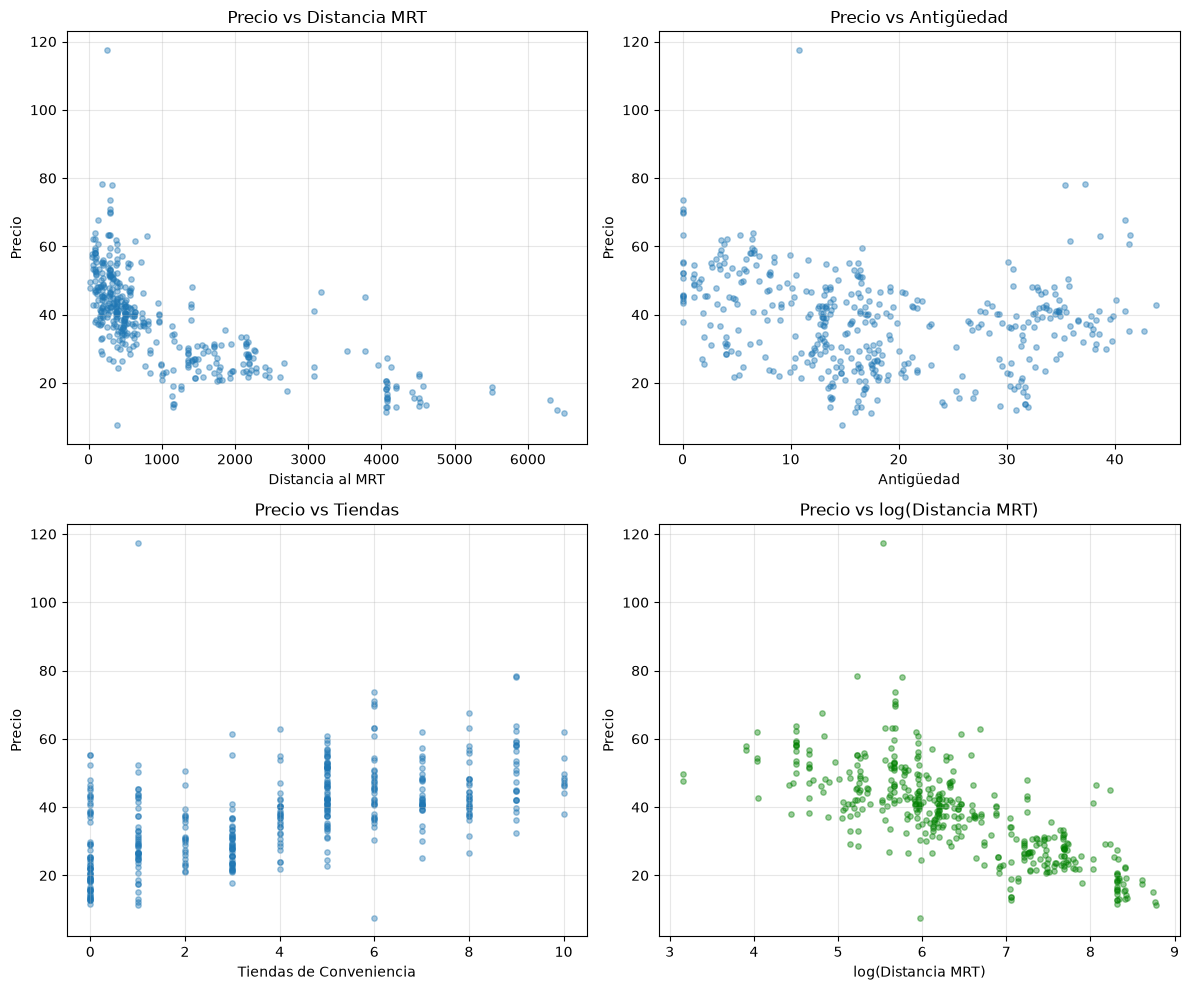

In [5]:
# Visualización de relaciones no-lineales
# Nota como cambia log(Distancia MRT) y sin la transformación
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Precio vs Distancia MRT
axes[0, 0].scatter(df['Distancia_MRT'], df['Precio'], alpha=0.4, s=15)
axes[0, 0].set_xlabel('Distancia al MRT')
axes[0, 0].set_ylabel('Precio')
axes[0, 0].set_title('Precio vs Distancia MRT')
axes[0, 0].grid(True, alpha=0.3)

# Precio vs Antigüedad
axes[0, 1].scatter(df['Antiguedad'], df['Precio'], alpha=0.4, s=15)
axes[0, 1].set_xlabel('Antigüedad')
axes[0, 1].set_ylabel('Precio')
axes[0, 1].set_title('Precio vs Antigüedad')
axes[0, 1].grid(True, alpha=0.3)

# Precio vs Tiendas
axes[1, 0].scatter(df['Tiendas_Conveniencia'], df['Precio'], alpha=0.4, s=15)
axes[1, 0].set_xlabel('Tiendas de Conveniencia')
axes[1, 0].set_ylabel('Precio')
axes[1, 0].set_title('Precio vs Tiendas')
axes[1, 0].grid(True, alpha=0.3)

# Precio vs log(Distancia MRT)
axes[1, 1].scatter(np.log(df['Distancia_MRT']), df['Precio'], alpha=0.4, s=15, color='green')
#axes[1, 1].scatter(df['Distancia_MRT'], df['Precio'], alpha=0.4, s=15, color='green')
#axes[1, 1].set_xlabel('Distancia MRT')
axes[1, 1].set_xlabel('log(Distancia MRT)')
axes[1, 1].set_ylabel('Precio')
axes[1, 1].set_title('Precio vs log(Distancia MRT)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

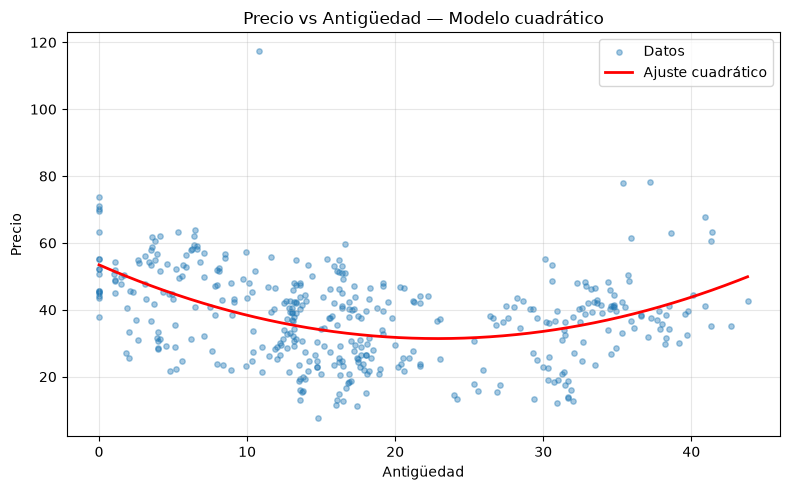

In [6]:
# Precio vs Antigüedad con transformación cuadrática
x = df['Antiguedad'].to_numpy()
y = df['Precio'].to_numpy()

coeficientes = np.polyfit(x, y, 2)
modelo_cuadratico = np.poly1d(coeficientes)

x_curva = np.linspace(x.min(), x.max(), 200)
y_curva = modelo_cuadratico(x_curva)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(x, y, alpha=0.4, s=15, label='Datos')
ax.plot(
    x_curva,
    y_curva,
    color='red',
    linewidth=2,
    label='Ajuste cuadrático'
)

ax.set_xlabel('Antigüedad')
ax.set_ylabel('Precio')
ax.set_title('Precio vs Antigüedad — Modelo cuadrático')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


PREGUNTAS DE ANÁLISIS - NO-LINEALIDAD:
1. ¿Qué variables muestran una relación no-lineal con el Precio?"
2. ¿La transformación logarítmica mejora la linealidad de la Distancia MRT? (Puedes comentar las lineas con log y sin el log para ver la diferencia)
3. ¿Qué tipo de transformación propondrías para cada variable?


 Escribe tus respuestas aquí:

1. Las variable que muestran una relacion no-lineal notable con el Precio es la Distancia MRT y la Antigüedad.
2. Si, al utilizar la transformacion logaritmica se logra notar una linealidad en la grafica, ya no se ve una forma de curva y se puede poner una linea encima sin perder muchos datos. 
3. Para Distancia MRT dejaria la transformación logarítmica. Para la variable de Antigüedad se puede sugerir una transformación cuadrática. Mientras que para la variable de tiendas mantendría la relación lineal inicial ya que no tiene una forma muy distinta notable para sugerir una transformación.


In [7]:
# Comparar modelos con y sin transformación
X = df.drop(['Precio', 'No'], axis=1)
y = df['Precio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo lineal con Distancia MRT
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train[['Distancia_MRT']], y_train)
y_pred_lineal = modelo_lineal.predict(X_test[['Distancia_MRT']])

# Modelo logarítmico con Distancia MRT
X_train_log = np.log(X_train[['Distancia_MRT']])
X_test_log = np.log(X_test[['Distancia_MRT']])

modelo_log = LinearRegression()
modelo_log.fit(X_train_log, y_train)
y_pred_log = modelo_log.predict(X_test_log)

# Comparar R²
print("=== COMPARACIÓN DE MODELOS ===")
print(f"Modelo Lineal (Distancia MRT):")
print(f"  R² = {metrics.r2_score(y_test, y_pred_lineal):.4f}")
print(f"  RMSE = {np.sqrt(metrics.mean_squared_error(y_test, y_pred_lineal)):.4f}")
print(f"\nModelo Logarítmico (log Distancia MRT):")
print(f"  R² = {metrics.r2_score(y_test, y_pred_log):.4f}")
print(f"  RMSE = {np.sqrt(metrics.mean_squared_error(y_test, y_pred_log)):.4f}")

=== COMPARACIÓN DE MODELOS ===
Modelo Lineal (Distancia MRT):
  R² = 0.4277
  RMSE = 9.7827

Modelo Logarítmico (log Distancia MRT):
  R² = 0.5053
  RMSE = 9.0952


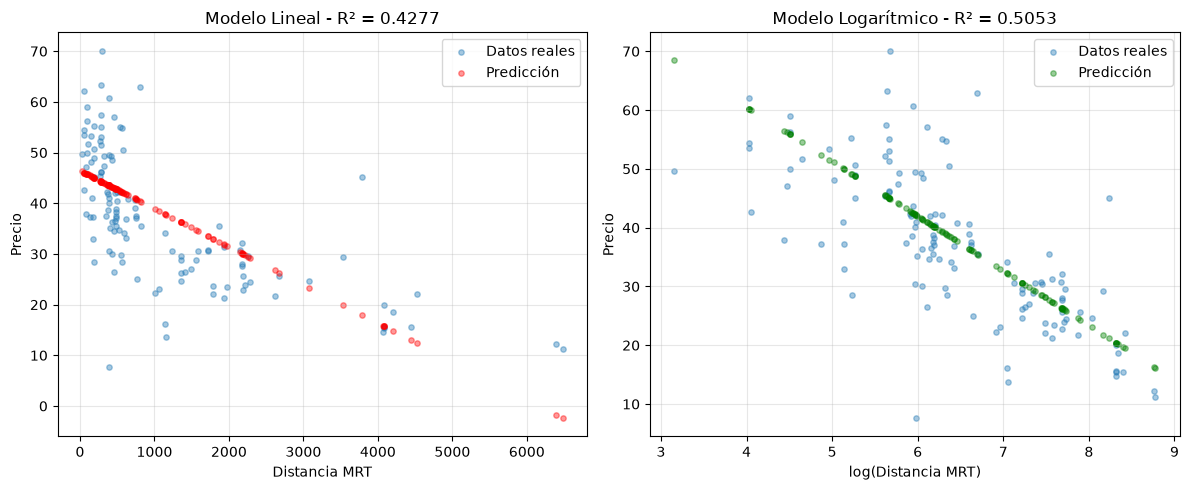

In [8]:
# Visualizar la mejora de la transformación
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Modelo lineal
axes[0].scatter(X_test['Distancia_MRT'], y_test, alpha=0.4, s=15, label='Datos reales')
axes[0].scatter(X_test['Distancia_MRT'], y_pred_lineal, alpha=0.4, s=15, color='red', label='Predicción')
axes[0].set_xlabel('Distancia MRT')
axes[0].set_ylabel('Precio')
axes[0].set_title(f'Modelo Lineal - R² = {metrics.r2_score(y_test, y_pred_lineal):.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Modelo logarítmico
axes[1].scatter(X_test_log, y_test, alpha=0.4, s=15, label='Datos reales')
axes[1].scatter(X_test_log, y_pred_log, alpha=0.4, s=15, color='green', label='Predicción')
axes[1].set_xlabel('log(Distancia MRT)')
axes[1].set_ylabel('Precio')
axes[1].set_title(f'Modelo Logarítmico - R² = {metrics.r2_score(y_test, y_pred_log):.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
#  Regresión polinómica de diferentes grados
print("=== REGRESIÓN POLINÓMICA ===")

grados = [1, 2, 3, 4]
resultados = []

for grado in grados:
    # Crear pipeline con transformación polinómica
    modelo_poly = make_pipeline(
        PolynomialFeatures(degree=grado, include_bias=False),
        LinearRegression()
    )
    
    # Entrenar
    modelo_poly.fit(X_train[['Distancia_MRT']], y_train)
    y_pred_poly = modelo_poly.predict(X_test[['Distancia_MRT']])
    
    # Métricas
    r2 = metrics.r2_score(y_test, y_pred_poly)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred_poly))
    aic = len(y_test) * np.log(metrics.mean_squared_error(y_test, y_pred_poly)) + 2 * (grado + 1)
    
    resultados.append({
        'Grado': grado,
        'R²': r2,
        'RMSE': rmse,
        'AIC': aic
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.round(4))

=== REGRESIÓN POLINÓMICA ===
   Grado      R²     RMSE       AIC
0      1  0.4277   9.7827  574.1541
1      2  0.4789   9.3353  564.4499
2      3  0.3128  10.7201  601.0312
3      4  0.2282  11.3604  617.5336


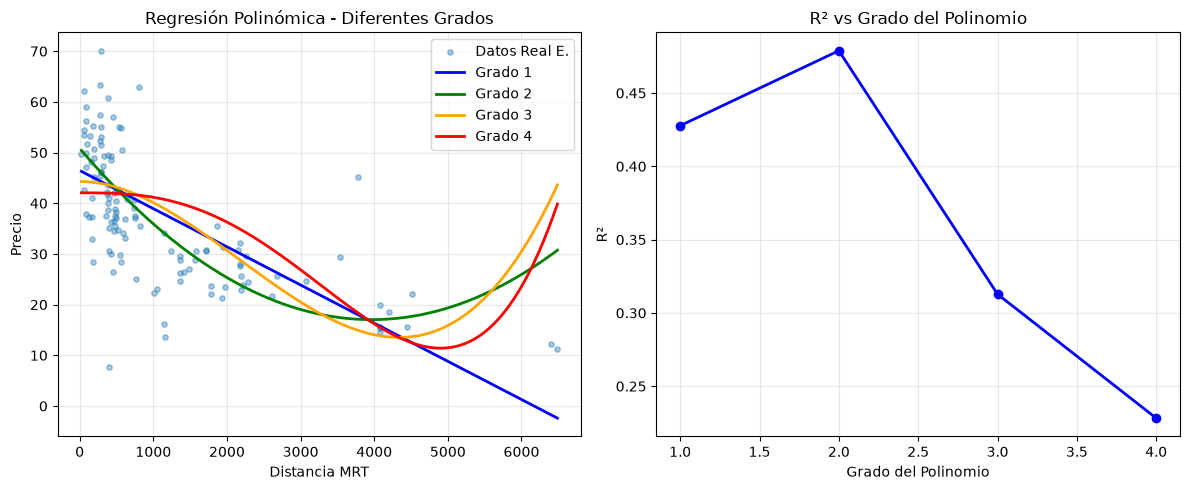

In [10]:
# Visualizar regresión polinómica
plt.figure(figsize=(12, 5))

# Gráfico de datos
plt.subplot(1, 2, 1)
plt.scatter(X_test['Distancia_MRT'], y_test, alpha=0.4, s=15, label='Datos Real E.')

# Crear rango para predicciones suaves
X_range = np.linspace(X_test['Distancia_MRT'].min(), X_test['Distancia_MRT'].max(), 100).reshape(-1, 1)

for grado, color in zip([1, 2, 3, 4], ['blue', 'green', 'orange', 'red']):
    modelo_poly = make_pipeline(
        PolynomialFeatures(degree=grado, include_bias=False),
        LinearRegression()
    )
    modelo_poly.fit(X_train[['Distancia_MRT']], y_train)
    y_range = modelo_poly.predict(X_range)
    plt.plot(X_range, y_range, color=color, linewidth=2, label=f'Grado {grado}')

plt.xlabel('Distancia MRT')
plt.ylabel('Precio')
plt.title('Regresión Polinómica - Diferentes Grados')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico de R² vs Grado
plt.subplot(1, 2, 2)
plt.plot(df_resultados['Grado'], df_resultados['R²'], 'o-', color='blue', linewidth=2)
plt.xlabel('Grado del Polinomio')
plt.ylabel('R²')
plt.title('R² vs Grado del Polinomio')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 Preguntas de análisis - Polinomios

PREGUNTAS DE ANÁLISIS - POLINOMIOS:

1.  ¿Qué grado de polinomio da el mejor R²?
2. ¿Hay evidencia de sobreajuste con grados altos?
3. ¿Qué grado seleccionarías según AIC?"

 Escribe tus respuestas aquí:

1. El grado cuadrático (2) es el grado de polinomio que da el mejor R2, con un valor cercano a 0.48
2. Es notable que en grados más altos, hay un sobreajuste. Con formas más complejas, el desempeño baja de tal manera que su capacidad de generalización es mucho peor que la regresion lineal
3. Ya que el grado cuadratico (2) tiene el menor valor de AIC con un valor de aproximadamente 564.45, se seleccionaria este.


In [11]:
#  Modelo completo y análisis de residuos
X_const = sm.add_constant(X)
modelo_completo = sm.OLS(y, X_const).fit()
print(modelo_completo.summary())

                            OLS Regression Results                            
Dep. Variable:                 Precio   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.576
Method:                 Least Squares   F-statistic:                     94.59
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           4.86e-74
Time:                        19:40:47   Log-Likelihood:                -1487.0
No. Observations:                 414   AIC:                             2988.
Df Residuals:                     407   BIC:                             3016.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -1.444e+04 

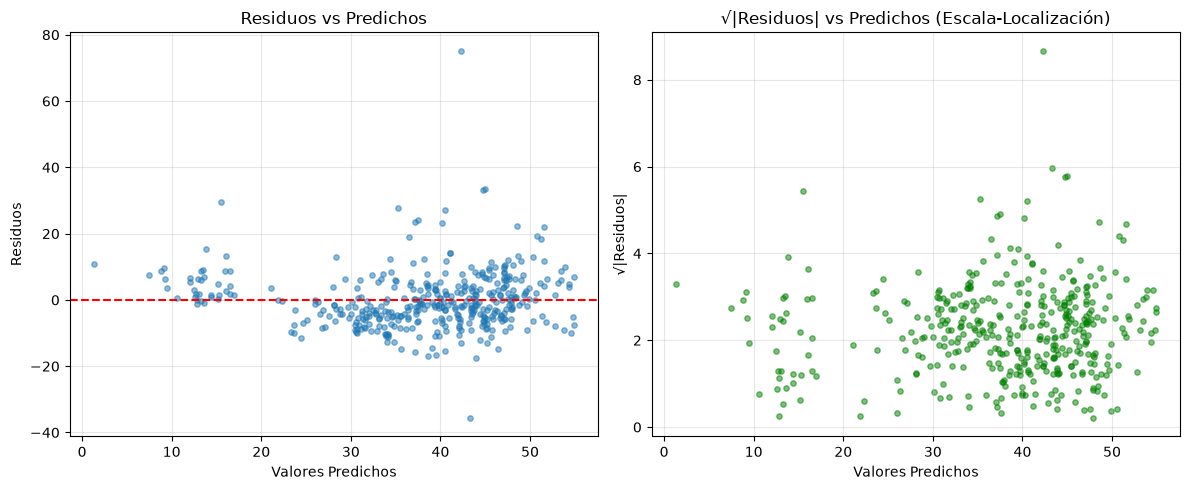

PREGUNTA: ¿Observas un patrón en forma de embudo?


In [12]:
# Visualización de residuos vs predichos
residuos = modelo_completo.resid
predichos = modelo_completo.fittedvalues

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(predichos, residuos, alpha=0.5, s=15)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs Predichos')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(predichos, np.sqrt(np.abs(residuos)), alpha=0.5, s=15, color='green')
plt.xlabel('Valores Predichos')
plt.ylabel('√|Residuos|')
plt.title('√|Residuos| vs Predichos (Escala-Localización)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("PREGUNTA: ¿Observas un patrón en forma de embudo?")


Escribe tu respuesta aquí:

En la gráfica de Residuos vs Predichos, aunque no se ve mucho, es posible ver dos distintos clusters notables y una ligera forma de embudo. El cluster a la izquierda es pequeño y la cluster de la derecha se agranda notablemente.
En la grafica de escala-localización, no se ve una forma de embudo en el patrón, solo se veuna tipo de variación en como se dispersan los residuos.

In [13]:
# Prueba de Breusch-Pagan
print("=== PRUEBA DE BREUSCH-PAGAN ===\n")

bp_test = het_breuschpagan(modelo_completo.resid, X_const)
print(f"LM Statistic: {bp_test[0]:.4f}")
print(f"LM p-value: {bp_test[1]:.4f}")
print(f"F Statistic: {bp_test[2]:.4f}")
print(f"F p-value: {bp_test[3]:.4f}")

if bp_test[1] < 0.05:
    print("\n❌ Rechazamos H₀: Hay evidencia de heteroscedasticidad")
else:
    print("\n✅ No rechazamos H₀: No hay evidencia suficiente de heteroscedasticidad")

=== PRUEBA DE BREUSCH-PAGAN ===

LM Statistic: 8.4591
LM p-value: 0.2064
F Statistic: 1.4149
F p-value: 0.2074

✅ No rechazamos H₀: No hay evidencia suficiente de heteroscedasticidad


In [15]:
from sklearn.preprocessing import StandardScaler

X_white = StandardScaler().fit_transform(X)
X_white = sm.add_constant(X_white)

white_test = het_white(modelo_completo.resid, X_white)

print("=== PRUEBA DE WHITE ===")
print(f"LM p-value: {white_test[1]:.4f}")
print(f"F p-value: {white_test[3]:.4f}")

=== PRUEBA DE WHITE ===
LM p-value: 0.6601
F p-value: 0.6722



PREGUNTAS DE ANÁLISIS - HETEROSCEDASTICIDAD:

1. ¿Qué concluyes de las pruebas de Breusch-Pagan y White?
2. ¿Los resultados son consistentes con el análisis visual?
3. ¿Qué implicaciones tiene para la inferencia?

Escribe tus respuestas aquí:
1. Breusch-Pagan tiene un p-valor de 0.2064 y White de 0.6601. Ambos son mayores que 0.05, así que no encontramos evidencia suficiente de heteroscedasticidad

2. Ligeramente si. En la grafica parece haber una ligera diferencia en la dispersión, visualmente se logra ver un patrón de heteroscedasticidad no tan notable con dos clusters de distintos tamaños.

3. Con los resultados, no hay evidencia suficiente para afirmar que si la heteroscedasticidad afecte la inferencia. Si existiera, los errores estándar y las pruebas de significancia del modelo pueden considerarse poco confiables.


In [16]:
# Errores estándar robustos (Sandwich)
print("=== SOLUCIÓN 1: ERRORES ESTÁNDAR ROBUSTOS ===\n")

# Modelo con errores robustos HC3
modelo_robusto = sm.OLS(y, X_const).fit(cov_type='HC3')

print("Comparación de errores estándar:")
print(f"{'Variable':<20} {'MCO':<15} {'Robusto':<15} {'Cambio %':<10}")
print("-" * 60)

for var in X_const.columns:
    se_mco = modelo_completo.bse[var]
    se_rob = modelo_robusto.bse[var]
    cambio = (se_rob - se_mco) / se_mco * 100
    print(f"{var:<20} {se_mco:<15.4f} {se_rob:<15.4f} {cambio:>+8.2f}%")

print("\n PREGUNTA: ¿Cómo cambian los errores estándar?")

# Escribe tu respuesta aquí

=== SOLUCIÓN 1: ERRORES ESTÁNDAR ROBUSTOS ===

Comparación de errores estándar:
Variable             MCO             Robusto         Cambio %  
------------------------------------------------------------
const                6775.6707       5598.1457         -17.38%
Fecha_Transaccion    1.5571          1.4696             -5.62%
Antiguedad           0.0385          0.0431            +11.73%
Distancia_MRT        0.0007          0.0008            +16.36%
Tiendas_Conveniencia 0.1882          0.2317            +23.13%
Latitud              44.5667         46.7949            +5.00%
Longitud             48.5820         44.1002            -9.23%

 PREGUNTA: ¿Cómo cambian los errores estándar?


Escribe tu respuesta aquí:
Los errores estándar cambian en ambas direcciones. Por ejemplo, aumentan 23.13% para Tiendas de Conveniencia y disminuyen 17.38% para la constante.


In [17]:
#  Mínimos Cuadrados Ponderados (WLS)
print("=== SOLUCIÓN 2: MÍNIMOS CUADRADOS PONDERADOS (WLS) ===\n")

# Estimar la varianza usando los residuos al cuadrado
# Modelo auxiliar: log(e²) ~ X
residuos_sq = modelo_completo.resid ** 2
log_residuos_sq = np.log(residuos_sq + 1e-10)  # Evitar log(0)

modelo_aux = sm.OLS(log_residuos_sq, X_const).fit()
var_predicha = np.exp(modelo_aux.fittedvalues)

# Pesos = 1/varianza
pesos = 1 / var_predicha

# Modelo WLS
modelo_wls = sm.WLS(y, X_const, weights=pesos).fit()

print("Comparación de coeficientes:")
print(f"{'Variable':<20} {'MCO':<15} {'WLS':<15} {'Cambio %':<10}")
print("-" * 60)

for var in X_const.columns:
    coef_mco = modelo_completo.params[var]
    coef_wls = modelo_wls.params[var]
    cambio = (coef_wls - coef_mco) / abs(coef_mco) * 100
    print(f"{var:<20} {coef_mco:<15.4f} {coef_wls:<15.4f} {cambio:>+8.2f}%")

print("\n PREGUNTA: ¿Cómo cambian los coeficientes estimados?")

# Escribe tu respuesta aquí

=== SOLUCIÓN 2: MÍNIMOS CUADRADOS PONDERADOS (WLS) ===

Comparación de coeficientes:
Variable             MCO             WLS             Cambio %  
------------------------------------------------------------
const                -14437.1008     -10816.4160       +25.08%
Fecha_Transaccion    5.1462          4.3956            -14.59%
Antiguedad           -0.2697         -0.3029           -12.32%
Distancia_MRT        -0.0045         -0.0038           +15.81%
Tiendas_Conveniencia 1.1333          1.3931            +22.93%
Latitud              225.4730        227.2422           +0.78%
Longitud             -12.4236        -30.1560         -142.73%

 PREGUNTA: ¿Cómo cambian los coeficientes estimados?


Escribe tu respuesta aquí:
WLS cambia los coeficientes porque asigna distintos pesos a las observaciones. Por ejemplo el coeficiente de Tiendas de Conveniencia pasa de 1.1333 a 1.3931 y el de Antigüedad de -0.2697 a -0.3029. Tambien se presenta el mayor cambio en el coeficiente de Longitud con alrededor de 142% de cambio.

In [18]:
# Comparación de modelos con diferentes soluciones
print("=== COMPARACIÓN DE SOLUCIONES ===\n")

print("Modelo MCO (sin corrección):")
print(f"  R² = {modelo_completo.rsquared:.4f}")
print(f"  AIC = {modelo_completo.aic:.2f}")
print(f"  BIC = {modelo_completo.bic:.2f}")

print("\nModelo Robusto (HC3):")
print(f"  R² = {modelo_robusto.rsquared:.4f}")
print(f"  AIC = {modelo_robusto.aic:.2f}")
print(f"  BIC = {modelo_robusto.bic:.2f}")

print("\nModelo WLS:")
print(f"  R² = {modelo_wls.rsquared:.4f}")
print(f"  AIC = {modelo_wls.aic:.2f}")
print(f"  BIC = {modelo_wls.bic:.2f}")

=== COMPARACIÓN DE SOLUCIONES ===

Modelo MCO (sin corrección):
  R² = 0.5824
  AIC = 2987.92
  BIC = 3016.11

Modelo Robusto (HC3):
  R² = 0.5824
  AIC = 2987.92
  BIC = 3016.11

Modelo WLS:
  R² = 0.7060
  AIC = 2919.51
  BIC = 2947.69



 PREGUNTAS DE ANÁLISIS - SOLUCIONES:

1. ¿Cuál solución prefieres y por qué?
2. ¿Los errores robustos cambian los coeficientes? ¿Por qué?
3. ¿Qué ventaja tiene WLS sobre los errores robustos?

Escribe tus respuestas aquí:
1. Prefiero MCO para este analisis, ya que ni Breusch-Pagan ni White encontraron evidencia suficiente de heteroscedasticidad. Si se requiere ser más cuidadoso con la inferencia, puedo usar sus errores estándar robustos HC3. El mayor R2 ponderado de WLS no basta para elegirlo.
2. No. Los errores robustos cambian los errores estándar, pero mantienen los coeficientes de MCO.
3. Si los pesos representan bien la varianza de los errores, WLS puede dar estimaciones de mejor precision. Su R2 no se compara directamente con el R2 de MCO porque usa pesos.


In [19]:
#  Detección de outliers
print("=== DETECCIÓN DE OUTLIERS ===\n")

# Calcular influencia
influencia = OLSInfluence(modelo_completo)

# Distancia de Cook
cook_dist = influencia.cooks_distance[0]
umbral_cook = 4 / len(y)

# Leverage
leverage = influencia.hat_matrix_diag
umbral_leverage = 2 * X_const.shape[1] / len(y)

# Residuos estandarizados
residuos_est = influencia.resid_studentized_internal

# Identificar outliers
outliers_cook = np.where(cook_dist > umbral_cook)[0]
outliers_leverage = np.where(leverage > umbral_leverage)[0]
outliers_residuos = np.where(np.abs(residuos_est) > 3)[0]

print(f"Distancia de Cook > {umbral_cook:.4f}: {len(outliers_cook)} observaciones")
print(f"Leverage > {umbral_leverage:.4f}: {len(outliers_leverage)} observaciones")
print(f"|Residuos estandarizados| > 3: {len(outliers_residuos)} observaciones")

=== DETECCIÓN DE OUTLIERS ===

Distancia de Cook > 0.0097: 19 observaciones
Leverage > 0.0338: 15 observaciones
|Residuos estandarizados| > 3: 7 observaciones


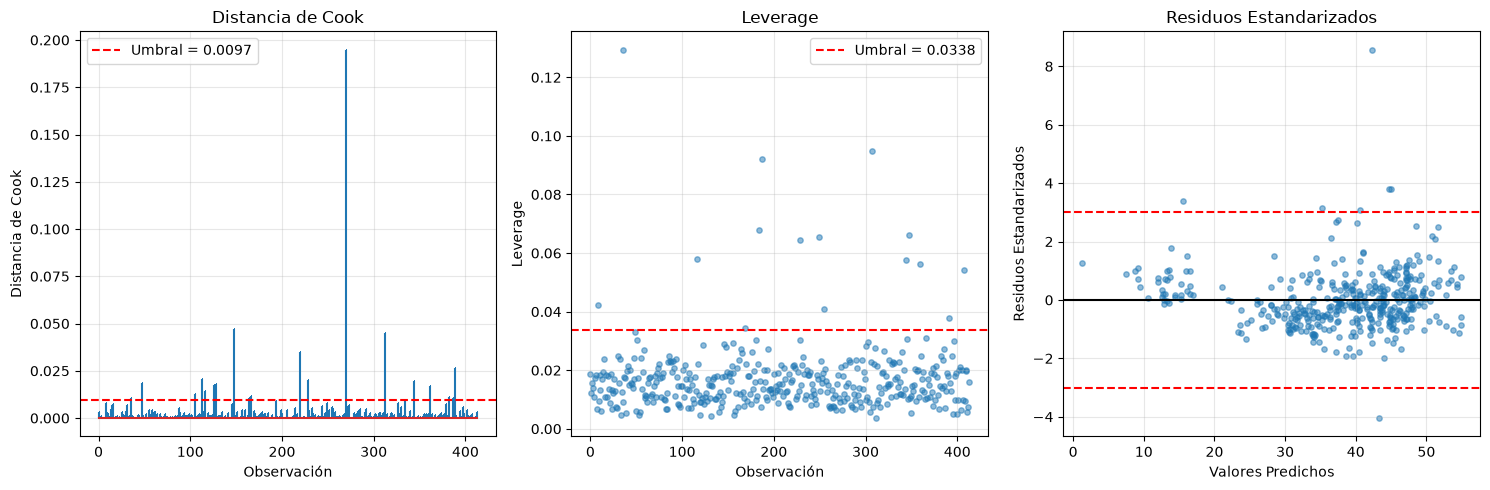

In [20]:
# Visualización de outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distancia de Cook
axes[0].stem(range(len(cook_dist)), cook_dist, markerfmt=',')
axes[0].axhline(y=umbral_cook, color='r', linestyle='--', label=f'Umbral = {umbral_cook:.4f}')
axes[0].set_xlabel('Observación')
axes[0].set_ylabel('Distancia de Cook')
axes[0].set_title('Distancia de Cook')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Leverage
axes[1].scatter(range(len(leverage)), leverage, alpha=0.5, s=15)
axes[1].axhline(y=umbral_leverage, color='r', linestyle='--', label=f'Umbral = {umbral_leverage:.4f}')
axes[1].set_xlabel('Observación')
axes[1].set_ylabel('Leverage')
axes[1].set_title('Leverage')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Residuos estandarizados
axes[2].scatter(modelo_completo.fittedvalues, residuos_est, alpha=0.5, s=15)
axes[2].axhline(y=3, color='r', linestyle='--')
axes[2].axhline(y=-3, color='r', linestyle='--')
axes[2].axhline(y=0, color='black', linestyle='-')
axes[2].set_xlabel('Valores Predichos')
axes[2].set_ylabel('Residuos Estandarizados')
axes[2].set_title('Residuos Estandarizados')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Regresión robusta con Huber
print("=== REGRESIÓN ROBUSTA (HUBER) ===\n")

from sklearn.linear_model import HuberRegressor

# Modelo Huber
huber = HuberRegressor(epsilon=1.35, max_iter=1000)
huber.fit(X_train, y_train)

# Predicciones
y_pred_huber = huber.predict(X_test)

# Comparar con MCO
modelo_mco = LinearRegression()
modelo_mco.fit(X_train, y_train)
y_pred_mco = modelo_mco.predict(X_test)

print("Comparación de coeficientes:")
print(f"{'Variable':<25} {'MCO':<15} {'Huber':<15}")
print("-" * 55)

for i, var in enumerate(X.columns):
    print(f"{var:<25} {modelo_mco.coef_[i]:<15.4f} {huber.coef_[i]:<15.4f}")

print(f"\n{'Intercept':<25} {modelo_mco.intercept_:<15.4f} {huber.intercept_:<15.4f}")

print("\nMétricas en test:")
print(f"MCO:   R² = {metrics.r2_score(y_test, y_pred_mco):.4f}, RMSE = {np.sqrt(metrics.mean_squared_error(y_test, y_pred_mco)):.4f}")
print(f"Huber: R² = {metrics.r2_score(y_test, y_pred_huber):.4f}, RMSE = {np.sqrt(metrics.mean_squared_error(y_test, y_pred_huber)):.4f}")

=== REGRESIÓN ROBUSTA (HUBER) ===

Comparación de coeficientes:
Variable                  MCO             Huber          
-------------------------------------------------------
Fecha_Transaccion         5.8478          0.0234         
Antiguedad                -0.2425         -0.2380        
Distancia_MRT             -0.0051         -0.0054        
Tiendas_Conveniencia      1.0745          1.3118         
Latitud                   239.0969        0.0423         
Longitud                  -52.2352        -0.0528        

Intercept                 -11350.7405     -0.0003        

Métricas en test:
MCO:   R² = 0.5601, RMSE = 8.5772
Huber: R² = 0.5519, RMSE = 8.6567


In [22]:
#  RANSAC
print("=== RANSAC ===\n")

from sklearn.linear_model import RANSACRegressor

# Modelo RANSAC
ransac = RANSACRegressor(
    estimator=LinearRegression(),
    min_samples=0.5,
    residual_threshold=5.0,
    random_state=42
)
ransac.fit(X_train, y_train)

# Predicciones
y_pred_ransac = ransac.predict(X_test)

print(f"Número de inliers: {ransac.inlier_mask_.sum()}")
print(f"Número de outliers: {(~ransac.inlier_mask_).sum()}")

print("\nMétricas en test:")
print(f"RANSAC: R² = {metrics.r2_score(y_test, y_pred_ransac):.4f}, RMSE = {np.sqrt(metrics.mean_squared_error(y_test, y_pred_ransac)):.4f}")

=== RANSAC ===

Número de inliers: 160
Número de outliers: 129

Métricas en test:
RANSAC: R² = 0.5225, RMSE = 8.9363


 PREGUNTAS DE ANÁLISIS - OUTLIERS:
1. ¿Cuántos outliers detectaste con cada método?
2. ¿Los coeficientes cambian significativamente con métodos robustos?
3. ¿Qué método recomendarías para este dataset?
Escribe tus respuestas aquí:

Responde Aca:
1. Se detectaron 19 observaciones con el umbral de Cook, 15 con leverage y 7 con residuos estandarizados mayores que 3 en valor absoluto. RANSAC marco 129 observaciones fuera de su grupo de inliers, pero como utiliza otro criterio no son necesariamente los mismos casos
2. Los coeficientes de Huber cambian bastante en algunas variables, pero las variables tienen escalas muy diferentes, lo que puede afectar ese ajuste. En test, Huber obtiene R2 de 0.5519 y MCO de 0.5601, así que Huber no mejora la predicción en esta comparación.
3. En este momento usaria MCO y revisaria las observaciones influyentes antes de quitarlas. RANSAC tiene un R2 menor (0.5225) y clasifica muchas observaciones como outliers.

In [ ]:
#!jupyter nbconvert --to html Act5-Regresionnolineal.ipynb

[NbConvertApp] Converting notebook Act5-Regresionnolineal.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1052567 bytes to Act5-Regresionnolineal.html
